To install, ´conda env create -f environment-VitisUnified.yml´, or to update env ´conda env update -f environment-VitisUnified.yml´. Remember to restart kernel.

In [1]:
# Check available backends for vitisunified
import hls4ml
hls4ml.backends.backend.get_available_backends()

['vivado',
 'vivadoaccelerator',
 'vitis',
 'vitisunified',
 'quartus',
 'catapult',
 'symbolicexpression',
 'oneapi',
 'libero']

# Example of creating a model and importing into a Vivado-project
Based on [hls4ml-tutorial part 3](https://github.com/fastmachinelearning/hls4ml-tutorial/blob/main/part3_compression.ipynb) and [Tanawin1701d/vitisUnifiedTutorial](https://github.com/Tanawin1701d/vitisUnifiedTutorial).

To store multiple revisions, the following parameters are used throughout. Make sure to update them if you want to keep multiple revisions.

Make sure to start this from conda environment with Vitis loaded to path.
´conda activate hls4ml-kv260-testenv´

In [2]:
import os
model_to_test = 'testmodel'
model_revision = 2
hls4ml_revision = 'VitisUnifiedKV260_2023.2'

base_dir = os.path.abspath(model_to_test)
model_dir = os.path.join(base_dir, str(model_revision))
os.makedirs(model_dir, exist_ok=True)

description = """
# Model Configuration

En simpel model for å teste A til Å med Vitis Unified på KV260.
Oppdatert fork som underlag.
Dummet ned til utrolig lite for å nå innenfor KV260-krav.
Kompilerer med Vitis/Vivado 2023.2.

- **Model architecture description**: {model_to_test}
- **Model Revision**: {model_revision}
- **HLS4ML Revision**: {hls4ml_revision}
- **Backend**: Vitis Unified [[https://github.com/fastmachinelearning/hls4ml/pull/1376]]
- **Target Device**: KV260 (xck26-sfvc784-2LV-c)
- **Dataset**: HLS4ML LHC Jets
"""
output_dir = os.path.join(model_dir, f"hls4ml_prj_{hls4ml_revision}")
os.makedirs(output_dir, exist_ok=True)
with open(os.path.join(output_dir, "description.md"), "w", encoding="utf-8") as f:
    f.write(description)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import os

%matplotlib inline
seed = 0
np.random.seed(seed)

tf.random.set_seed(seed)



2026-03-19 11:32:11.131248: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Kjøre 2023 eller 2025

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH'] 

In [5]:
#os.environ["PATH"]
!vitis --version
!vitis_hls -version
!vivado -version


****** Vitis Development Environment
****** Vitis v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:07
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
SW Build 4023990 on Oct 11 2023
IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
Tool Version Limit: 2023.10
Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.
SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023

vivado v2023.2 (64-bit)
Tool Version Limit: 2023.10
SW Build 4029153 on Fri Oct 13 20:13:54 MDT 2023
IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.


Load dataset and save data. If the data is already saved to disk, load the local cache.

In [6]:
# Use absolute paths for data files
x_train_val_path = os.path.join(base_dir, "x_train_val.npy")
x_test_path = os.path.join(base_dir, "x_test.npy")
y_train_val_path = os.path.join(base_dir, "y_train_val.npy")
y_test_path = os.path.join(base_dir, "y_test.npy")
classes_path = os.path.join(base_dir, "classes.npy")

if not os.path.exists(x_train_val_path):
    from tensorflow.keras.utils import to_categorical
    from sklearn.datasets import fetch_openml
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    
    data = fetch_openml('hls4ml_lhc_jets_hlf')
    x, y = data['data'], data['target']

    le = LabelEncoder()
    y = le.fit_transform(y)
    y = to_categorical(y, 5)
    x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    x_train_val = scaler.fit_transform(x_train_val)
    x_test = scaler.transform(x_test)

    np.save(x_train_val_path, x_train_val)
    np.save(x_test_path, x_test)
    np.save(y_train_val_path, y_train_val)
    np.save(y_test_path, y_test)
    np.save(classes_path, le.classes_)
else:
    x_train_val = np.load(x_train_val_path)
    x_test = np.load(x_test_path)
    y_train_val = np.load(y_train_val_path)
    y_test = np.load(y_test_path)
    classes = np.load(classes_path, allow_pickle=True)



In [ ]:
# Prepare subset of testdata for simulation (running everything takes an unnecessary long time)
x_test_path = os.path.join(base_dir, "x_test.npy")
y_test_path = os.path.join(base_dir, "y_test.npy")
np.save(

In [7]:
# Convert dataset arrays to float32
#x_train_val = x_train_val.astype(np.float32)
#x_test = x_test.astype(np.float32)
#y_train_val = y_train_val.astype(np.float32)
#y_test = y_test.astype(np.float32)

Load existing model, or create and train a new

In [8]:
load_existing_model = False

keras_model_path = os.path.join(model_dir, f"{model_to_test}_{model_revision}_model.h5")

if load_existing_model:
    from keras.models import load_model
    model = load_model(keras_model_path)
else:
    inputs = keras.Input(shape=(16,), name='linput')
    x = keras.layers.Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform')(inputs)
    #x = keras.layers.Activation(activation='relu', name='relu1')(x)
    #x = keras.layers.Dense(32, name='fc2', kernel_initializer='lecun_uniform')(x)
    #x = keras.layers.Activation(activation='relu', name='relu2')(x)
    #x = keras.layers.Dense(32, name='fc3', kernel_initializer='lecun_uniform')(x)
    x = keras.layers.Activation(activation='relu', name='relu3')(x)
    x = keras.layers.Dense(5, name='output', kernel_initializer='lecun_uniform')(x)
    outputs = keras.layers.Activation(activation='softmax', name='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(optimizer="adam", loss=['categorical_crossentropy'], metrics=['accuracy'])
    model.fit(
        x_train_val,
        y_train_val,
        batch_size=1024,
        epochs=3,
        validation_split=0.25,
        shuffle=True,
    )
    model.save(keras_model_path)


In [9]:
# Save the model summary to a text file (Keras 3 style)
with open(os.path.join(model_dir, "summary.txt"), "w", encoding="utf-8") as f:
    model.summary(print_fn=lambda line: f.write(line + "\n"))

# Convert and synthesize with HLS4ML
Uses KV260 (xck26-sfvc784-2LV-c). You need to set the xpfm-path manually (it should be set based on env-path in source code?)

In [10]:
XPFM_PATH = '/usr/lib/AMD/2025.2/Vitis/base_platforms/xilinx_kv260_base_202520_1/xilinx_kv260_base_202520_1.xpfm'
#XPFM_PATH = (   "/tools/Xilinx/Vitis/2023.2/base_platforms/xilinx_zcu102_base_202320_1/xilinx_zcu102_base_202320_1.xpfm")

In [12]:
import hls4ml
hls_model = hls4ml.converters.convert_from_keras_model(
    model, 
    backend     = 'vitisunified', 
    #project_name=f'{model_to_test}_{model_revision}_hls4ml_prj_{hls4ml_revision}', # Bug ved feil bruk av denne når axi_master.cpp skal hentes i ´vitis_unified_writer´
    output_dir  = output_dir, 
    board       = 'kv260',
    part        = 'xck26-sfvc784-2LV-c', # default fra supported-boards.json fungerer ikke i Vivado 2025.2
    clock_period= '5ns',
    # Set input data for model
    input_data_tb= x_test_path,
    output_data_tb=y_test_path,
    #in_stream_buf_size = 256,
    #out_stream_buf_size = 128,
    #input_type  = "float",
    #output_type = "float",
    #xpfmPath    = XPFM_PATH,
    #io_type     = "io_stream",
    #strategy    = "latency",
    #granularity = "name",
    #amt_query   = 10,
    #axi_mode    = "axi_master",
)
hls_model.compile()
#hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True,to_file=os.path.join(output_dir, "model-plot.png"))

# Problem 1
# Ved dette datasettet med float64-tall får vi 0-matrise ut av predictions.abs
# ATLAS-ML-for-FPGA/hls4ml-dev-testenv/testmodel/1/hls4ml_prj_VitisUnifiedKV260_1/myproject_bridge.cpp
# Nevermind, måtte spesifisere input_type="double", output_type="double" pga. inndata (float64). Default er float32
# Var feilen kun at vi kjørte convert_from.. to ganger, slik hls4ml-tutorial gjorde?

In [13]:
print(hls_model.config.config)
hls_model.config.get_output_dir()
hls_model.config.backend.writer.get_vitis_linker_dir(hls_model)

{'OutputDir': '/workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2', 'ProjectName': 'myproject', 'Backend': 'VitisUnified', 'Version': '1.0.0', 'Part': 'xck26-sfvc784-2LV-c', 'ClockPeriod': '5ns', 'ClockUncertainty': '12.5%', 'IOType': 'io_stream', 'HLSConfig': {'Model': {'Precision': 'fixed<16,6>', 'ReuseFactor': 1, 'BitExact': None}}, 'WriterConfig': {'Namespace': None, 'WriteWeightsTxt': True, 'WriteTar': False, 'TBOutputStream': 'both', 'WriteEmulationConstants': False}, 'VitisUnifiedConfig': {'Board': 'kv260', 'axi_mode': 'axi_master', 'in_stream_buf_size': 128, 'out_stream_buf_size': 128, 'Driver': 'python', 'InputDtype': 'float', 'OutputDtype': 'float'}, 'KerasModel': <Functional name=functional, built=True>, 'InputData': '/workspace/HLS4ML_testbench_KV260/development/testmodel/x_test.npy', 'OutputPredictions': '/workspace/HLS4ML_testbench_KV260/development/testmodel/y_test.npy', 'InputShapes': {'linput': [16]}, 'OutputShapes': {'layer5_

'/workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/vitis_workspace/system_link'

Test the HLS-model if it actually works

In [14]:
hls_model.predict(np.ascontiguousarray(x_test[:10]))

array([[0.5       , 0.4013672 , 0.03710938, 0.05371094, 0.12988281],
       [0.08691406, 0.6669922 , 0.00390625, 0.19726562, 0.11914062],
       [0.22851562, 0.08105469, 0.7998047 , 0.        , 0.        ],
       [0.0078125 , 0.00878906, 0.6669922 , 0.44335938, 0.        ],
       [0.02148438, 0.02636719, 1.        , 0.00585938, 0.        ],
       [0.04492188, 0.12695312, 0.57128906, 0.09570312, 0.29589844],
       [0.44433594, 0.22265625, 0.16308594, 0.08984375, 0.08398438],
       [0.6669922 , 0.12304688, 0.0546875 , 0.11914062, 0.08984375],
       [0.05566406, 0.57128906, 0.01171875, 0.20996094, 0.18457031],
       [0.00195312, 0.00683594, 0.01464844, 0.7998047 , 0.1953125 ]],
      dtype=float32)

# Simulation
[vitis unified tutorial](https://github.com/Tanawin1701d/vitis_unified_backend_tutorial/blob/master/03_co_simulation.ipynb)

Ubuntu 24 not supported compiling files for co-sim (glibc missmatch). Using 22-docker for running the cosim.

```bash
sudo docker run  -it -d -p 8888:8888 --name pyct -v /home/ncgadmin/Bachelor:/workspace   -v /tools/Xilinx:/tools/Xilinx   -w /workspace   ubuntu:22.04 bash

sudo docker exec -ti pyct bash

apt update

# Vitis installasjongreier
apt-get install -y locales
sed -i 's/^# *en_US.UTF-8 UTF-8/en_US.UTF-8 UTF-8/' /etc/locale.gen
locale-gen
update-locale LANG=en_US.UTF-8 LC_ALL=en_US.UTF-8

bash /tools/Xilinx/Vitis/2023.2/scripts/installLibs.sh

# Python greier
apt install python3-pip python3 git

curl -O https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh

bash Miniconda3-latest-Linux-x86_64.sh


curl -O https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
bash Miniconda3-latest-Linux-x86_64.sh

cd HLS4ML_testbench_KV260/development/

source /tools/Xilinx/Vitis_HLS/2023.2/settings64.sh
source /tools/Xilinx/Vivado/2023.2/settings64.sh
source /tools/Xilinx/Model_Composer/2023.2/settings64.sh
source /tools/Xilinx/Vitis/2023.2/settings64.sh

conda activate devenv-vu
jupyter notebook --allow-root --ip=0.0.0.0


In [ ]:
# Build and do co-simulation
hls_model.build(
    #synth=True, # Only needs to run first time
    cosim=True,
    ) 

# Problem 1 19.03.2026
# Version missmatch mellom system glibc og Vitis 2023.2 (binutils)
# Kjøre i Ubuntu 22 docker, se over


****** v++ v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

Running Dispatch Server on port: 45517
INFO: [v++ 60-1548] Creating build summary session with primary output /workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/vitis_workspace/myproject/vitis_unified_project/vitis_unified_project.hlscompile_summary, at Thu Mar 19 11:32:56 2026
INFO: [v++ 82-31] Launching vitis_hls: vitis_hls -nolog -run csynth -work_dir /workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/vitis_workspace/myproject/vitis_unified_project -config /workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/hls_kernel_config.cfg -cmdlineconfig /workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/vitis_work

In [ ]:
y_baseline = hls_model.predict(np.ascontiguousarray(x_test))
y_simulation = np.loadtxt(os.path.join(output_dir, "tb_data/rtl_cosim_results.log"))

In [ ]:
print(f"y_baseline shape: {y_baseline.shape} and y_simulation: {y_simulation.shape}")
print(y_simulation)

In [ ]:
assert np.allclose(y_baseline[:5], y_simulation, rtol=0.0, atol=1e-4), (
    "The results from bridge and cosim are NOT equal!"
)
print("\n✅ RTL co-simulation comparison passed (atol=1e-4).")

In [ ]:
from sklearn.metrics import accuracy_score
print("Difference in inference-calculations between HLS4ML bridge and simulated inference (first rows):")
for x,y in enumerate(y_baseline[:5]):
    print(f"{y-y_simulation[x]}")

print("Baseline  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_baseline, axis=1))))
print("Simulation Accuracy: {}".format(accuracy_score(np.argmax(y_test[:5], axis=1), np.argmax(y_simulation, axis=1))))

# Generate bitfile

Implementation details
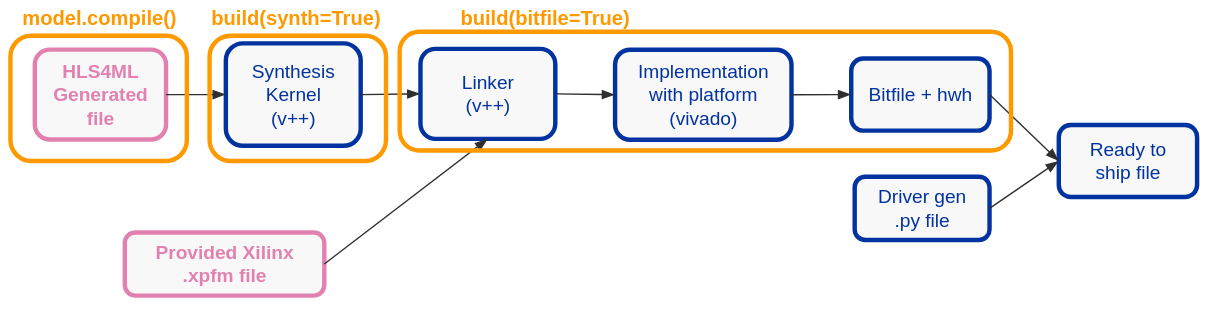
[Origin and more information](https://github.com/fastmachinelearning/hls4ml/pull/1376)

In [54]:
#hls_model.build(csim=False)

# Create IP-blokk ()
hls_model.build(
    #csim=False,
    synth=True, 
    bitfile=True
    ) 

# Problem 4, 05.03.2026
# updated Vitis Unified med native KV260. Feil part i default config
# ERROR: [HLS 200-1023] Part 'sk-kv260-g' is not installed.
# Fix: override part='xck26-sfvc784-2LV-c'

# Problem 5, 05.03.2026
# Error med build under create_xsa.tcl
# source create_xsa.tcl -> feil i kv260_axi_all_platform.tcl
# ERROR: [BD::TCL 103-2041] This script was generated using Vivado <2023.2> and is being run in <2025.2> of Vivado. Please run the script in Vivado <2023.2> then open the design in Vivado <2025.2>. Upgrade the design by running "Tools => Report => Report IP Status...", then run write_bd_tcl to create an updated script.
# Fila har en egen sjekk for Vivado-versjon 2023.2
# Hotfix: Fjernet sjekken, restartet kernel (?) og det kompilerte greit (~/miniconda3/envs/hls4ml-kv260-testenv/lib/python3.11/site-packages/hls4ml/templates/vitis_unified/kv260/tcl_scripts/kv260_axi_all_platform.tcl)
# Fix 2: Kjøre i 2023


****** v++ v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

Running Dispatch Server on port: 45937
INFO: [v++ 60-1548] Creating build summary session with primary output /workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/vitis_workspace/myproject/vitis_unified_project/vitis_unified_project.hlscompile_summary, at Thu Mar 19 11:26:32 2026
INFO: [v++ 82-31] Launching vitis_hls: vitis_hls -nolog -run csynth -work_dir /workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/vitis_workspace/myproject/vitis_unified_project -config /workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/hls_kernel_config.cfg -cmdlineconfig /workspace/HLS4ML_testbench_KV260/development/testmodel/2/hls4ml_prj_VitisUnifiedKV260_2023.2/vitis_work

KeyboardInterrupt: 

In [ ]:
hls4ml.report.read_vivado_report(output_dir)
hls4ml.report.read_vivado_report(os.path.join(output_dir,"final_reports/"))

# Run inference
Created a notebook in "onboard-verification" for the devkit. The following is just to print results to test against hw.

In [1]:
model_pred = model.predict(x_test[:10])
hls4ml_pred = hls_model.predict(np.ascontiguousarray(x_test[:10]))

print(model_pred, '\n', hls4ml_pred, '\n', y_test[:10])


NameError: name 'model' is not defined